# Trial Activation Analysis — Task 1 (Part 2): Conversion Driver Analysis
**Splendor Analytics Data Challenge**

This notebook covers:
1. Org-level feature engineering
2. Statistical tests (Mann-Whitney U, Chi-squared, Point-Biserial)
3. ML feature importance (Random Forest + SHAP)
4. Lift & Odds Ratio analysis
5. Engagement segmentation (K-Means)
6. Trial Goal definition

---
## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

SEED = 42
np.random.seed(SEED)
print('Libraries loaded successfully')

Libraries loaded successfully


---
## 2. Load Cleaned Data

In [2]:
df = pd.read_parquet('../data/processed/cleaned_events.parquet')
print(f'Events loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Unique orgs  : {df["organization_id"].nunique():,}')
df.head(3)

Events loaded: 102,895 rows x 10 cols
Unique orgs  : 966


,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,trial_day,days_to_convert,module
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53+00:00,False,NaT,2024-03-27 10:11:39+00:00,2024-04-26 10:11:39+00:00,0,NaN,Scheduling
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52+00:00,False,NaT,2024-03-27 10:11:39+00:00,2024-04-26 10:11:39+00:00,0,NaN,Scheduling
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53+00:00,False,NaT,2024-03-27 10:11:39+00:00,2024-04-26 10:11:39+00:00,0,NaN,Scheduling


---
## 3. Org-Level Feature Engineering

We collapse the event log into **one row per organisation** with aggregate behavioural features. This is the feature matrix used for all downstream analyses.

In [3]:
# ── Activity-level pivot: count of each activity per org ──────────────
activity_counts = (
    df.groupby(['organization_id', 'activity_name'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# ── Org-level aggregates ───────────────────────────────────────────────
org_agg = df.groupby('organization_id').agg(
    converted            = ('converted', 'first'),
    total_events         = ('activity_name', 'count'),
    unique_activities    = ('activity_name', 'nunique'),
    active_days          = ('trial_day', 'nunique'),
    first_event_day      = ('trial_day', 'min'),
    last_event_day       = ('trial_day', 'max'),
    days_to_convert      = ('days_to_convert', 'first'),
    modules_used         = ('module', 'nunique'),
).reset_index()

# Events per active day
org_agg['events_per_active_day'] = (
    org_agg['total_events'] / org_agg['active_days'].replace(0, np.nan)
)

# Trial span: days between first and last event
org_agg['trial_span_days'] = org_agg['last_event_day'] - org_agg['first_event_day']

# ── Module flags: did org use each module? ─────────────────────────────
module_flags = (
    df.groupby(['organization_id', 'module'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)  # binary flag
    .reset_index()
)
module_flags.columns = (
    ['organization_id'] +
    [f'used_{c.lower()}' for c in module_flags.columns[1:]]
)

# ── Merge all features ─────────────────────────────────────────────────
org_feat = (
    org_agg
    .merge(activity_counts, on='organization_id', how='left')
    .merge(module_flags, on='organization_id', how='left')
    .fillna(0)
)

# Cast converted to bool
org_feat['converted'] = org_feat['converted'].astype(bool)

print(f'Feature matrix: {org_feat.shape[0]:,} orgs x {org_feat.shape[1]} features')
print(f'Conversion rate: {org_feat["converted"].mean():.1%}')
org_feat.head(3)

Feature matrix: 966 orgs x 44 features
Conversion rate: 21.3%


,organization_id,converted,total_events,unique_activities,active_days,first_event_day,last_event_day,days_to_convert,modules_used,events_per_active_day,trial_span_days,Absence.Request.Approved,Absence.Request.Created,Absence.Request.Rejected,Break.Activate.Finished,Break.Activate.Started,Communication.Message.Created,Integration.Xero.PayrollExport.Synced,Mobile.Schedule.Loaded,PunchClock.Entry.Edited,PunchClock.PunchedIn,PunchClock.PunchedOut,PunchClockEndNote.Add.Completed,PunchClockStartNote.Add.Completed,Revenue.Budgets.Created,Scheduling.Availability.Set,Scheduling.OpenShiftRequest.Approved,Scheduling.OpenShiftRequest.Created,Scheduling.Shift.Approved,Scheduling.Shift.AssignmentChanged,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed,used_absence,used_communications,used_payroll,used_punchclock,used_scheduling
0,0040dd9ab132b92d5d04bc3acf14d2e2,False,1004,14,11,0,29,0.0000,4,91.2727,29,3,3,1,0,0,9,0,11,1,1,0,0,1,0,1,0,0,2,384,576,0,0,0,0,10,0,1,0,1,1,0,1,1
1,00456fd86311b6095ad05f7e31758f0d,False,6,4,1,0,0,0.0000,2,6.0000,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,3,1,0,0,0,0,0,0,0,0,0,1,0,0,1
2,007d48a2bc006e6eac0348c788d26dfd,False,5,2,2,0,1,0.0000,2,2.5000,1,0,0,0,0,0,0,0,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1


---
## 4. Statistical Tests

We use three complementary tests to identify features associated with conversion:
- **Mann-Whitney U** — non-parametric comparison of continuous feature distributions
- **Point-Biserial correlation** — linear association between continuous feature and binary label
- **Chi-squared** — association between binary feature flags and conversion

In [4]:
converted     = org_feat[org_feat['converted'] == True]
not_converted = org_feat[org_feat['converted'] == False]

# Continuous features to test
continuous_features = [
    'total_events', 'unique_activities', 'active_days',
    'events_per_active_day', 'trial_span_days', 'modules_used',
    'first_event_day', 'last_event_day',
]

stat_results = []
for feat in continuous_features:
    g1 = converted[feat].dropna()
    g2 = not_converted[feat].dropna()

    # Mann-Whitney U
    u_stat, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')

    # Point-Biserial
    y = org_feat['converted'].astype(int)
    x = org_feat[feat].fillna(0)
    pb_r, p_pb = pointbiserialr(y, x)

    stat_results.append({
        'feature'       : feat,
        'mean_converted': g1.mean(),
        'mean_not_conv' : g2.mean(),
        'ratio'         : g1.mean() / (g2.mean() + 1e-9),
        'mw_p_value'    : p_mw,
        'pb_r'          : pb_r,
        'pb_p_value'    : p_pb,
        'significant'   : p_mw < 0.05,
    })

stat_df = pd.DataFrame(stat_results).sort_values('pb_r', ascending=False)
print('Statistical test results (continuous features):')
stat_df

Statistical test results (continuous features):


,feature,mean_converted,mean_not_conv,ratio,mw_p_value,pb_r,pb_p_value,significant
4,trial_span_days,6.4223,5.7500,1.1169,0.6317,0.0268,0.4054,False
7,last_event_day,7.1699,6.5382,1.0966,0.8772,0.0238,0.4594,False
0,total_events,107.8786,106.1474,1.0163,0.8513,0.0021,0.9481,False
1,unique_activities,2.7767,2.7776,0.9997,0.6502,-0.0001,0.9964,False
2,active_days,4.1650,4.2066,0.9901,0.7330,-0.0024,0.9406,False
6,first_event_day,0.7476,0.7882,0.9485,0.2977,-0.0049,0.8800,False
5,modules_used,1.3932,1.4197,0.9813,0.9232,-0.0142,0.6595,False
3,events_per_active_day,12.8377,14.1826,0.9052,0.8644,-0.0242,0.4531,False


In [5]:
# Chi-squared test for binary module flags
flag_cols = [c for c in org_feat.columns if c.startswith('used_')]
chi2_results = []

for feat in flag_cols:
    ct = pd.crosstab(org_feat['converted'], org_feat[feat])
    chi2, p, dof, _ = chi2_contingency(ct)

    # Adoption rate per group
    rate_conv  = converted[feat].mean()
    rate_nc    = not_converted[feat].mean()
    lift       = rate_conv / (rate_nc + 1e-9)

    chi2_results.append({
        'module_flag'          : feat,
        'adoption_converted'   : rate_conv,
        'adoption_not_conv'    : rate_nc,
        'lift'                 : lift,
        'chi2'                 : chi2,
        'p_value'              : p,
        'significant'          : p < 0.05,
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('lift', ascending=False)
print('Chi-squared test results (module flags):')
chi2_df

Chi-squared test results (module flags):


,module_flag,adoption_converted,adoption_not_conv,lift,chi2,p_value,significant
3,used_punchclock,0.2330,0.2145,1.0864,0.2266,0.6340,False
4,used_scheduling,1.0000,0.9842,1.0160,2.1322,0.1442,False
0,used_absence,0.0388,0.0421,0.9223,0.0001,0.9906,False
1,used_communications,0.1165,0.1592,0.7318,1.9943,0.1579,False
2,used_payroll,0.0049,0.0197,0.2460,1.3848,0.2393,False


### 4.1 Visualise — Converted vs Not: Key Continuous Features

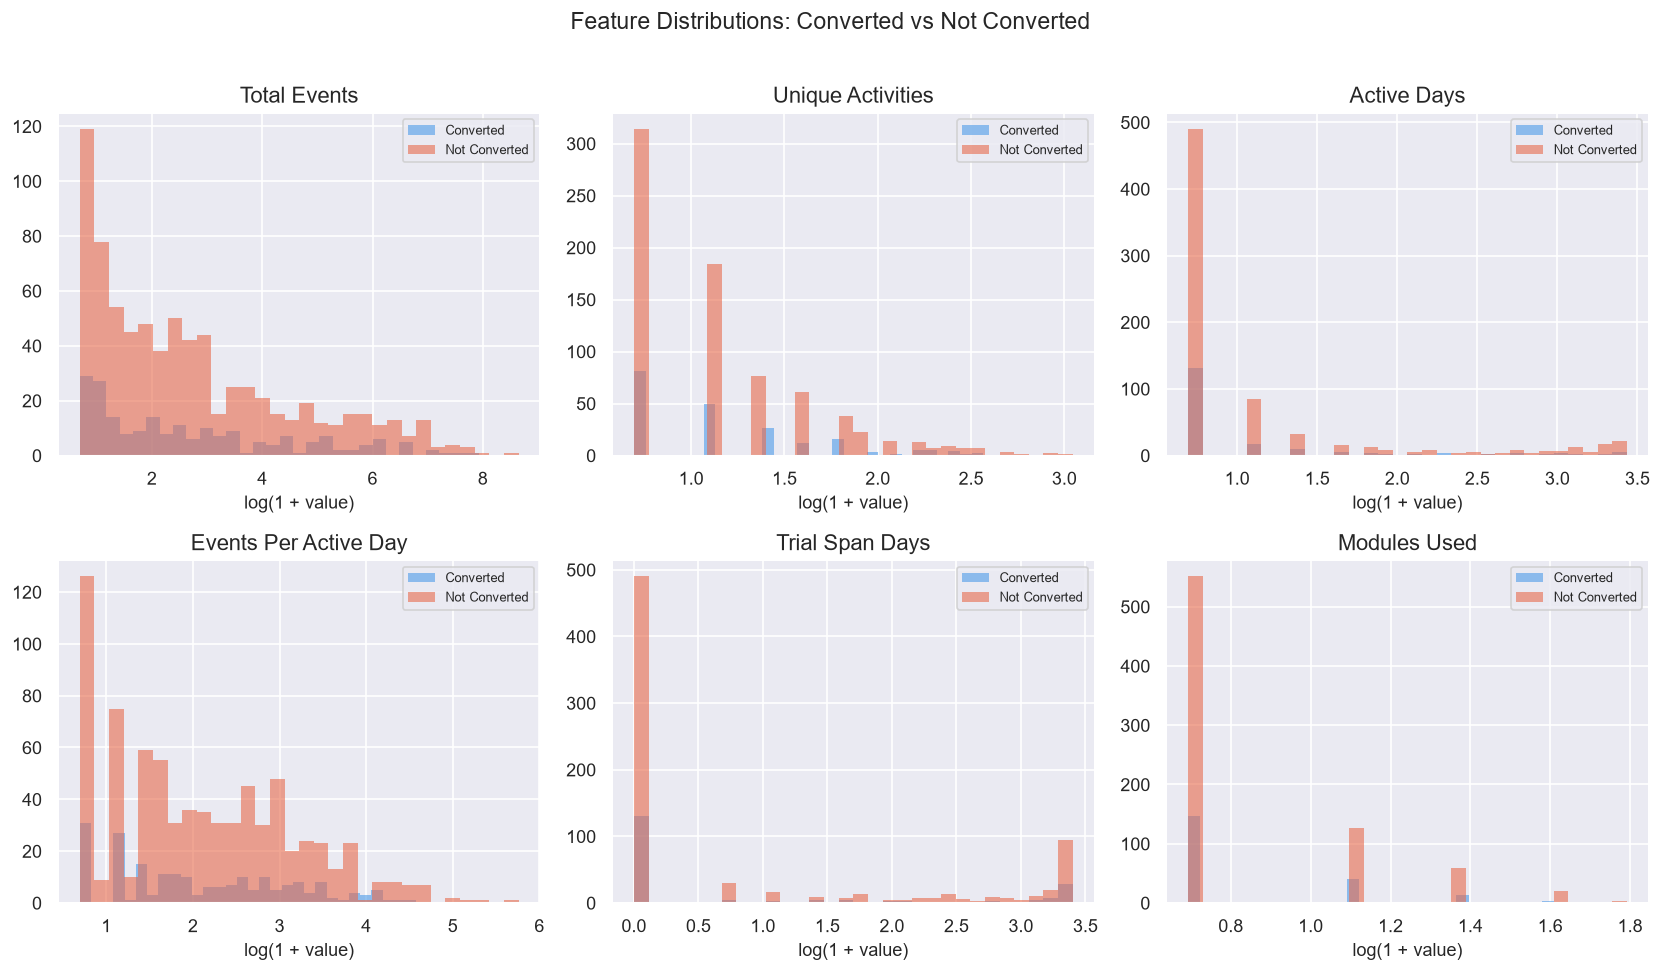

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

plot_feats = [
    'total_events', 'unique_activities', 'active_days',
    'events_per_active_day', 'trial_span_days', 'modules_used'
]

for ax, feat in zip(axes, plot_feats):
    for val, label, color in [
        (True,  'Converted',     '#4C9BE8'),
        (False, 'Not Converted', '#E86B4C'),
    ]:
        data = org_feat[org_feat['converted'] == val][feat].dropna()
        ax.hist(np.log1p(data), bins=30, alpha=0.6,
                label=label, color=color, edgecolor='none')
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('log(1 + value)')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Converted vs Not Converted', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Lift & Odds Ratio Analysis

For every activity we compute:
- **Usage rate** among converters vs non-converters
- **Lift** = conversion rate when activity used / baseline
- **Odds Ratio** with 95% confidence interval

In [7]:
activity_cols = [c for c in org_feat.columns
                 if c not in (
                     ['organization_id', 'converted', 'total_events',
                      'unique_activities', 'active_days', 'first_event_day',
                      'last_event_day', 'days_to_convert', 'modules_used',
                      'events_per_active_day', 'trial_span_days']
                     + flag_cols
                 )]

baseline_rate = org_feat['converted'].mean()
lift_results  = []

for col in activity_cols:
    used     = org_feat[org_feat[col] > 0]
    not_used = org_feat[org_feat[col] == 0]
    if len(used) < 10:
        continue

    rate_used     = used['converted'].mean()
    rate_not_used = not_used['converted'].mean() if len(not_used) > 0 else np.nan
    lift          = rate_used / (baseline_rate + 1e-9)

    # Odds ratio
    a = used['converted'].sum()
    b = len(used) - a
    c = not_used['converted'].sum()
    d = len(not_used) - c

    # Guard against zero cells
    if b == 0 or c == 0:
        or_val, or_lo, or_hi = np.nan, np.nan, np.nan
    else:
        or_val = (a * d) / (b * c)
        log_se = np.sqrt(1/a + 1/b + 1/c + 1/d) if all(x > 0 for x in [a,b,c,d]) else np.nan
        or_lo  = np.exp(np.log(or_val) - 1.96 * log_se) if log_se == log_se else np.nan
        or_hi  = np.exp(np.log(or_val) + 1.96 * log_se) if log_se == log_se else np.nan

    # Chi-squared p-value
    ct = pd.crosstab(org_feat['converted'], (org_feat[col] > 0))
    _, p, _, _ = chi2_contingency(ct) if ct.shape == (2, 2) else (None, 1.0, None, None)

    lift_results.append({
        'activity'         : col,
        'orgs_using'       : len(used),
        'usage_pct'        : len(used) / len(org_feat),
        'conv_rate_used'   : rate_used,
        'conv_rate_unused' : rate_not_used,
        'lift'             : lift,
        'odds_ratio'       : or_val,
        'or_ci_lo'         : or_lo,
        'or_ci_hi'         : or_hi,
        'p_value'          : p,
        'significant'      : p < 0.05,
    })

lift_df = pd.DataFrame(lift_results).sort_values('lift', ascending=False)
print(f'Activities analysed: {len(lift_df)}')
lift_df.head(15)

Activities analysed: 18


,activity,orgs_using,usage_pct,conv_rate_used,conv_rate_unused,lift,odds_ratio,or_ci_lo,or_ci_hi,p_value,significant
13,Scheduling.ShiftHandover.Created,11,0.0114,0.3636,0.2115,1.7052,2.1301,0.6175,7.3482,0.3928,False
9,Scheduling.OpenShiftRequest.Created,43,0.0445,0.3023,0.2091,1.4177,1.6390,0.8388,3.2026,0.2046,False
2,Absence.Request.Rejected,14,0.0145,0.2857,0.2122,1.3398,1.4851,0.4610,4.7847,0.7352,False
15,Scheduling.Template.ApplyModal.Applied,108,0.1118,0.2500,0.2086,1.1723,1.2644,0.7937,2.0143,0.3872,False
5,PunchClock.PunchedIn,211,0.2184,0.2275,0.2093,1.0668,1.1127,0.7712,1.6053,0.6340,False
8,Scheduling.Availability.Set,59,0.0611,0.2203,0.2128,1.0332,1.0455,0.5536,1.9746,1.0000,False
10,Scheduling.Shift.Approved,200,0.2070,0.2200,0.2115,1.0317,1.0516,0.7214,1.5329,0.8691,False
12,Scheduling.Shift.Created,848,0.8778,0.2182,0.1780,1.0230,1.2889,0.7824,2.1231,0.3795,False
11,Scheduling.Shift.AssignmentChanged,343,0.3551,0.2157,0.2119,1.0117,1.0233,0.7422,1.4107,0.9535,False
4,Mobile.Schedule.Loaded,456,0.4720,0.2127,0.2137,0.9975,0.9940,0.7302,1.3531,1.0000,False


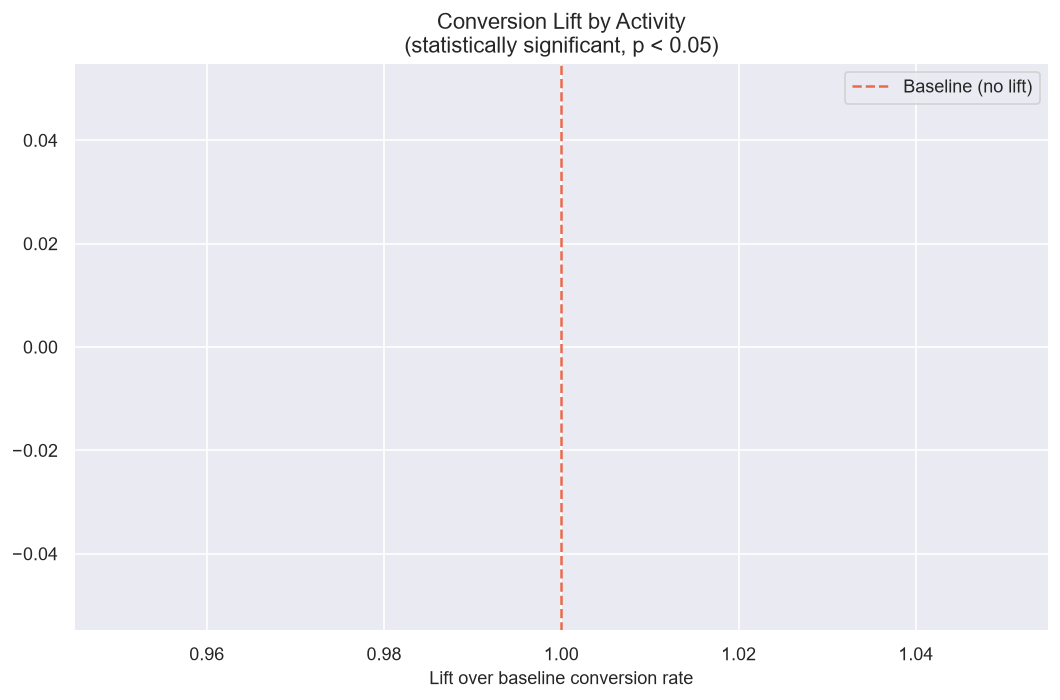

In [8]:
# Plot: Lift by activity (top 15)
top_lift = lift_df[lift_df['significant']].head(15).sort_values('lift')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4C9BE8' if l >= 1.5 else '#8BB8E8' for l in top_lift['lift']]
bars = ax.barh(top_lift['activity'].str.replace('.', '\n', 1),
               top_lift['lift'], color=colors, edgecolor='none', alpha=0.88)
ax.axvline(1.0, color='#E86B4C', linestyle='--', linewidth=1.5,
           label='Baseline (no lift)')
ax.set_xlabel('Lift over baseline conversion rate')
ax.set_title('Conversion Lift by Activity\n(statistically significant, p < 0.05)')
ax.legend()
plt.tight_layout()
plt.show()

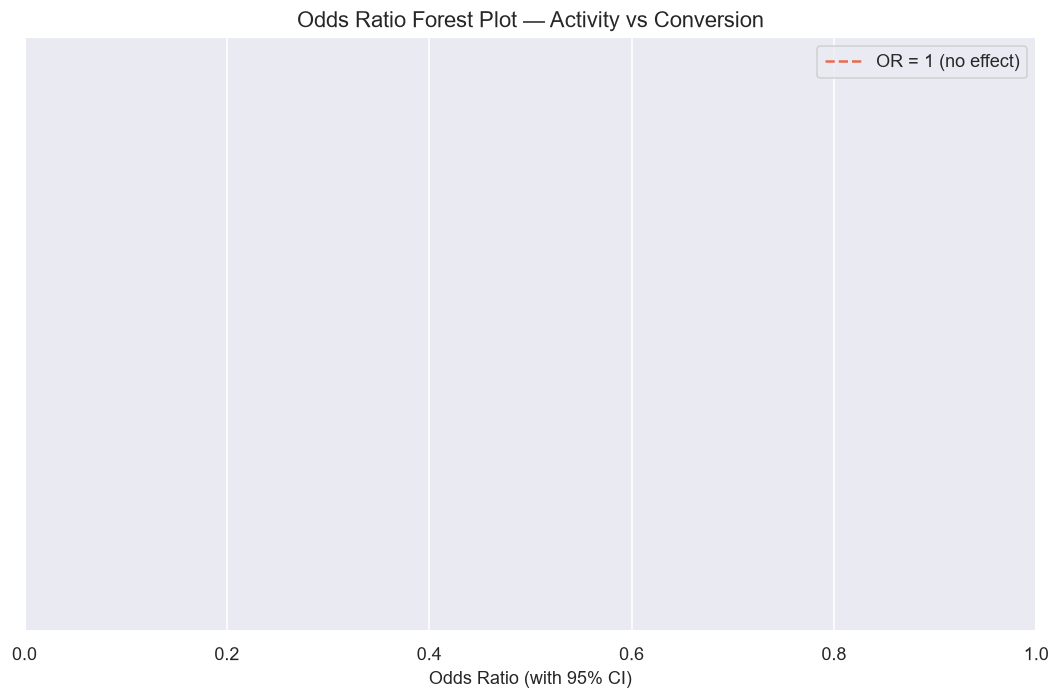

In [9]:
# Plot: Odds ratio forest plot (top 12 significant)
top_or = lift_df[lift_df['significant'] & lift_df['odds_ratio'].notna()].head(12)
top_or = top_or.sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(top_or))

for i, (_, row) in enumerate(top_or.iterrows()):
    ax.plot([row['or_ci_lo'], row['or_ci_hi']], [i, i],
            color='#4C9BE8', linewidth=2, alpha=0.6)
    ax.scatter(row['odds_ratio'], i, color='#4C9BE8', s=60, zorder=3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_or['activity'].str.split('.').str[-1].tolist())
ax.axvline(1.0, color='#E86B4C', linestyle='--', linewidth=1.5, label='OR = 1 (no effect)')
ax.set_xlabel('Odds Ratio (with 95% CI)')
ax.set_title('Odds Ratio Forest Plot — Activity vs Conversion')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. ML Feature Importance: Random Forest + SHAP

A Random Forest classifier is trained on the org-level feature matrix. We validate with cross-validated AUC, then extract SHAP values for interpretability.

In [10]:
# Build feature matrix (drop id and target)
drop_cols = ['organization_id', 'converted', 'days_to_convert']
feature_cols = [c for c in org_feat.columns if c not in drop_cols]

X = org_feat[feature_cols].fillna(0).astype(float)
y = org_feat['converted'].astype(int)

print(f'Feature matrix: {X.shape[0]:,} orgs x {X.shape[1]} features')
print(f'Class balance : {y.mean():.1%} positive')

Feature matrix: 966 orgs x 41 features
Class balance : 21.3% positive


In [11]:
# Cross-validated AUC
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
auc_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print(f'Cross-validated AUC: {auc_scores.mean():.3f} +/- {auc_scores.std():.3f}')
print(f'Fold scores: {[round(s, 3) for s in auc_scores]}')

Cross-validated AUC: 0.483 +/- 0.059
Fold scores: [np.float64(0.533), np.float64(0.372), np.float64(0.5), np.float64(0.48), np.float64(0.529)]


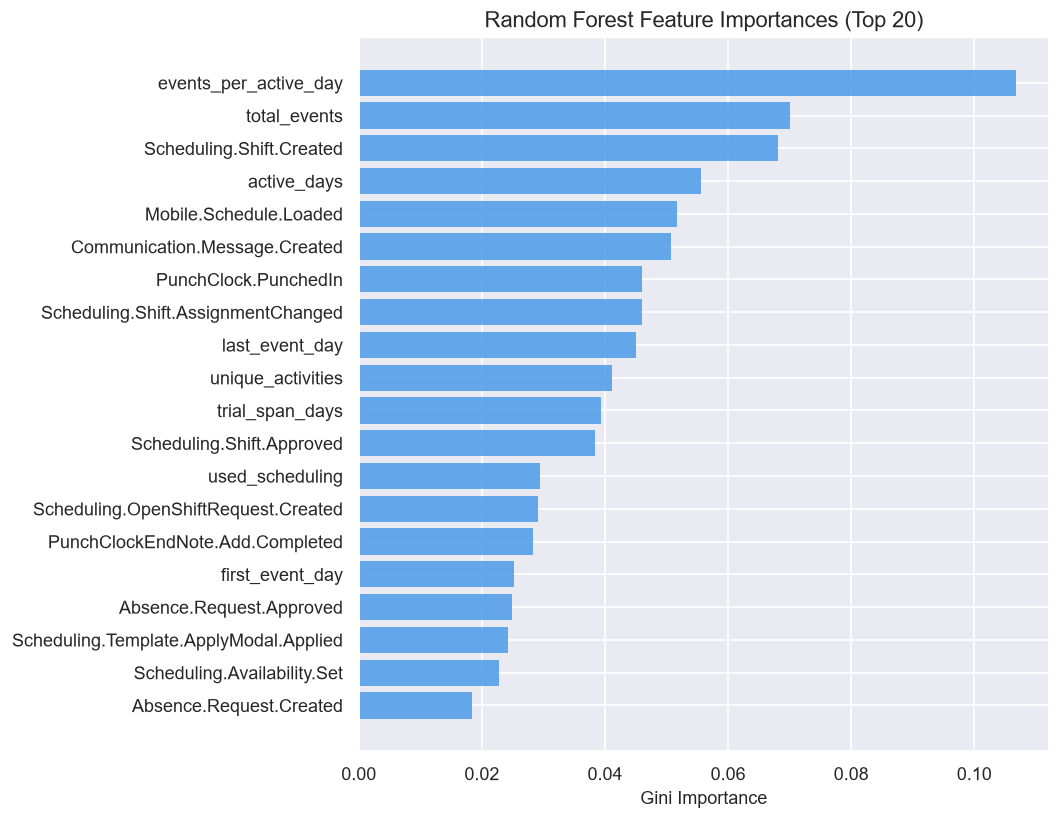

,feature,importance
6,events_per_active_day,0.1068
0,total_events,0.0700
27,Scheduling.Shift.Created,0.0681
2,active_days,0.0555
15,Mobile.Schedule.Loaded,0.0517
13,Communication.Message.Created,0.0507
17,PunchClock.PunchedIn,0.0461
26,Scheduling.Shift.AssignmentChanged,0.0460
4,last_event_day,0.0450
1,unique_activities,0.0411


In [12]:
# Fit on full dataset for SHAP explanation
rf.fit(X, y)

# Gini feature importances
importance_df = (
    pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='#4C9BE8', edgecolor='none', alpha=0.85
)
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest Feature Importances (Top 20)')
plt.tight_layout()
plt.show()

importance_df

<Figure size 1200x840 with 0 Axes>

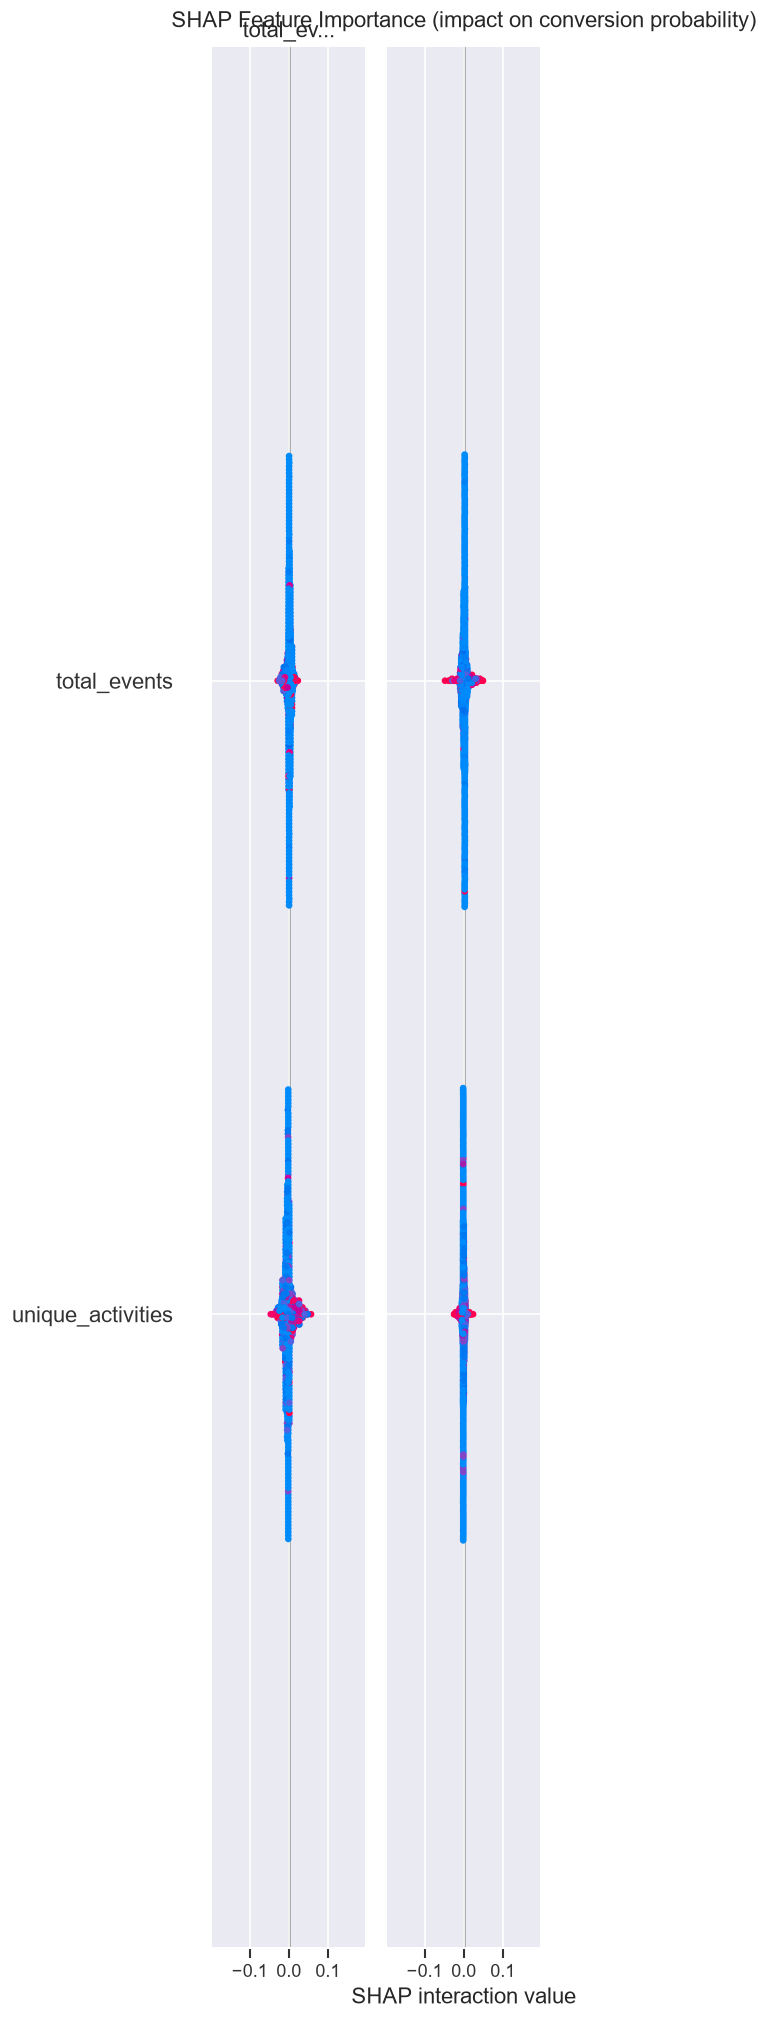

In [13]:
# SHAP values — TreeExplainer
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X)

# shap_vals is a list [class0, class1]; use class1 (converted)
shap_class1 = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_class1, X,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance (impact on conversion probability)', pad=12)
plt.tight_layout()
plt.show()

<Figure size 1200x960 with 0 Axes>

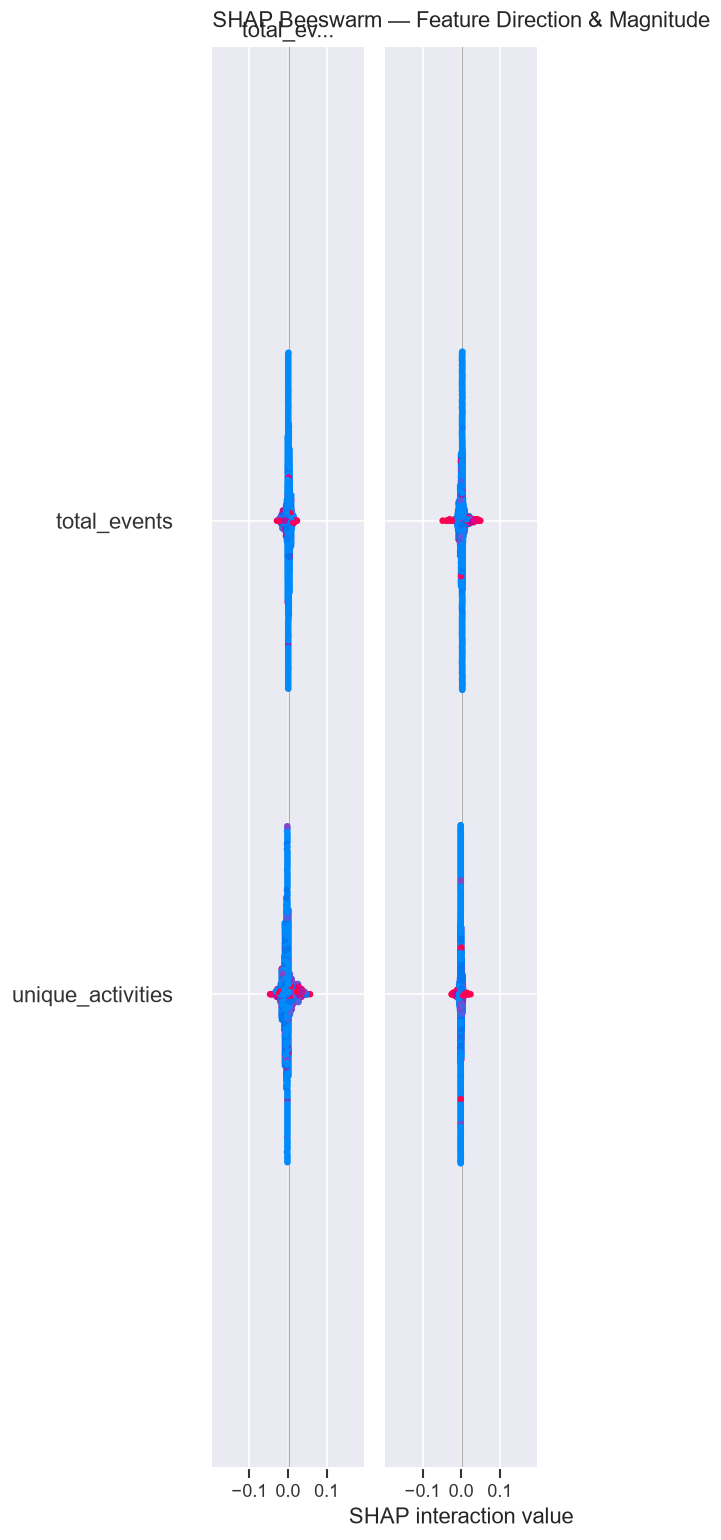

In [14]:
# SHAP beeswarm — direction of effect
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_class1, X,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude', pad=12)
plt.tight_layout()
plt.show()

---
## 7. Engagement Segmentation (K-Means)

We cluster organisations by behavioural engagement to discover natural groupings and profile their conversion rates.

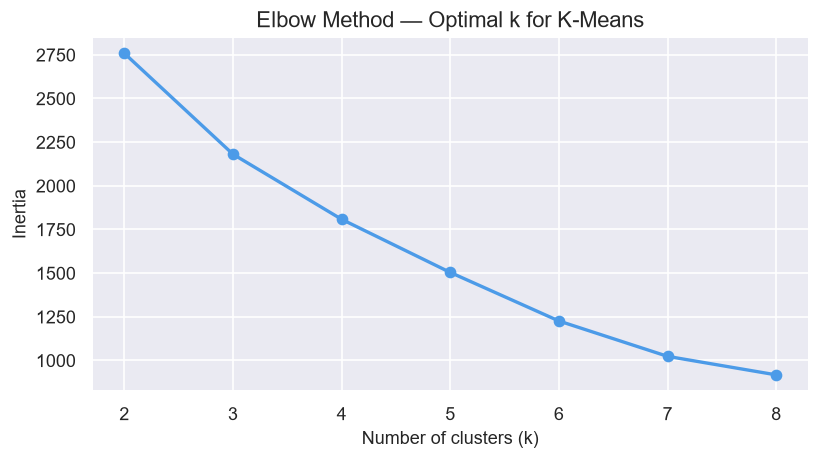

In [15]:
# Use core engagement features for clustering
cluster_features = [
    'total_events', 'unique_activities', 'active_days',
    'events_per_active_day', 'modules_used', 'trial_span_days'
]

X_cluster = org_feat[cluster_features].fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

# Elbow method to pick k
inertias = []
k_range  = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='#4C9BE8', linewidth=2)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal k for K-Means')
plt.tight_layout()
plt.show()

In [16]:
# Fit final K-Means (k=4 — adjust if elbow suggests otherwise)
K = 4
km_final = KMeans(n_clusters=K, random_state=SEED, n_init=10)
org_feat['segment'] = km_final.fit_predict(X_scaled)

# Profile each segment
seg_profile = (
    org_feat.groupby('segment')
    .agg(
        n_orgs               = ('organization_id', 'count'),
        conversion_rate      = ('converted', 'mean'),
        avg_total_events     = ('total_events', 'mean'),
        avg_unique_activities= ('unique_activities', 'mean'),
        avg_active_days      = ('active_days', 'mean'),
        avg_modules_used     = ('modules_used', 'mean'),
    )
    .sort_values('conversion_rate', ascending=False)
    .round(2)
)

print('Segment profiles:')
seg_profile

Segment profiles:


,n_orgs,conversion_rate,avg_total_events,avg_unique_activities,avg_active_days,avg_modules_used
segment,,,,,,
1,139,0.2400,269.6900,6.1300,14.8300,2.4600
0,762,0.2100,12.7000,1.7900,1.3800,1.1300
2,34,0.2100,"1,483.8500",10.6800,25.8200,3.4400
3,31,0.1900,170.1900,3.2600,1.9400,1.3900


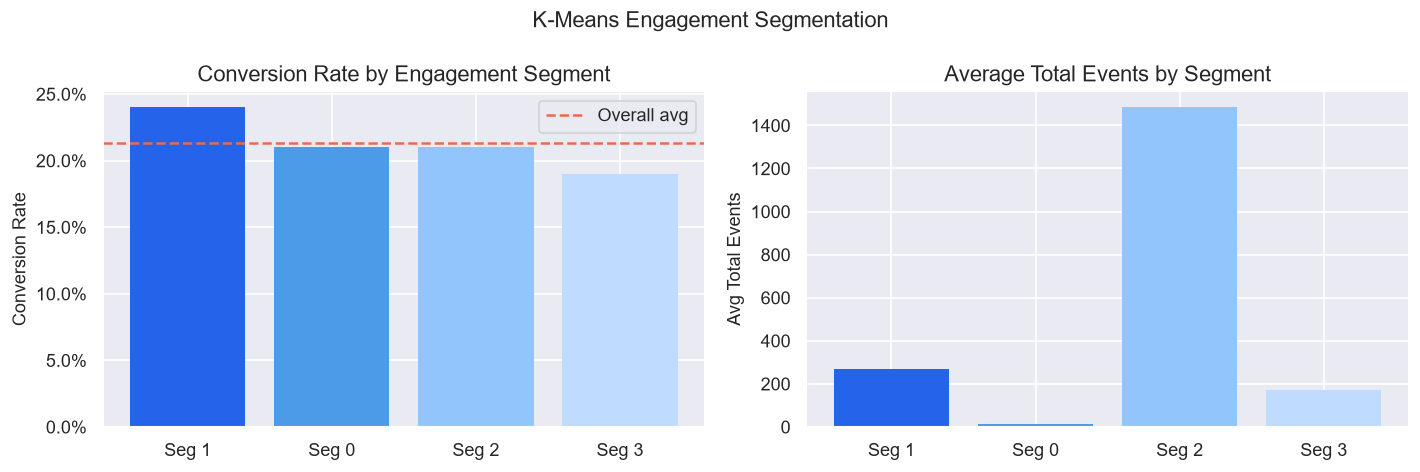

In [17]:
# Visualise: conversion rate by segment
seg_sorted = seg_profile.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conversion rate bar
axes[0].bar(
    [f'Seg {i}' for i in seg_sorted['segment']],
    seg_sorted['conversion_rate'],
    color=['#2563EB', '#4C9BE8', '#93C5FD', '#BFDBFE'],
    edgecolor='none'
)
axes[0].axhline(org_feat['converted'].mean(), color='#E86B4C',
                linestyle='--', linewidth=1.5, label='Overall avg')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_title('Conversion Rate by Engagement Segment')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()

# Avg events bar
axes[1].bar(
    [f'Seg {i}' for i in seg_sorted['segment']],
    seg_sorted['avg_total_events'],
    color=['#2563EB', '#4C9BE8', '#93C5FD', '#BFDBFE'],
    edgecolor='none'
)
axes[1].set_ylabel('Avg Total Events')
axes[1].set_title('Average Total Events by Segment')

plt.suptitle('K-Means Engagement Segmentation', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Trial Goal Definition

Based on the statistical tests, ML feature importance, and lift analysis, we define **Trial Goals** — specific in-app behaviours that signal a trialist has genuinely experienced the product's core value.

> **Important:** These goals are data-grounded hypotheses, not guaranteed conversion levers. They should be validated through experimentation.

In [18]:
# ── Compute completion rates for candidate goals ───────────────────────
goals = {
    'goal_scheduling_setup': (
        'Created at least 1 shift AND set availability',
        (org_feat.get('Scheduling.Shift.Created', pd.Series(0, index=org_feat.index)) >= 1) &
        (org_feat.get('Scheduling.Availability.Set', pd.Series(0, index=org_feat.index)) >= 1)
    ),
    'goal_schedule_viewed': (
        'Viewed the schedule at least 3 times (Mobile.Schedule.Loaded)',
        org_feat.get('Mobile.Schedule.Loaded', pd.Series(0, index=org_feat.index)) >= 3
    ),
    'goal_team_comms': (
        'Sent at least 1 team communication message',
        org_feat.get('Communication.Message.Created', pd.Series(0, index=org_feat.index)) >= 1
    ),
    'goal_punch_clock': (
        'Used punch clock at least once (PunchedIn or PunchedOut)',
        (org_feat.get('PunchClock.PunchedIn', pd.Series(0, index=org_feat.index)) >= 1) |
        (org_feat.get('PunchClock.PunchedOut', pd.Series(0, index=org_feat.index)) >= 1)
    ),
    'goal_active_engagement': (
        'Active on at least 5 distinct days during trial',
        org_feat['active_days'] >= 5
    ),
}

goal_rows = []
for goal_name, (description, mask) in goals.items():
    completed    = org_feat[mask]
    not_completed= org_feat[~mask]
    completion   = mask.mean()
    conv_if_done = completed['converted'].mean() if len(completed) > 0 else 0
    conv_if_not  = not_completed['converted'].mean() if len(not_completed) > 0 else 0
    lift_val     = conv_if_done / (org_feat['converted'].mean() + 1e-9)

    goal_rows.append({
        'goal'                  : goal_name,
        'description'           : description,
        'completion_rate'       : completion,
        'conv_rate_if_completed': conv_if_done,
        'conv_rate_if_missed'   : conv_if_not,
        'lift'                  : lift_val,
    })

goal_df = pd.DataFrame(goal_rows).sort_values('lift', ascending=False)
print('Trial Goal Candidates:')
goal_df.round(3)

Trial Goal Candidates:


,goal,description,completion_rate,conv_rate_if_completed,conv_rate_if_missed,lift
4,goal_active_engagement,Active on at least 5 distinct days during trial,0.1850,0.2350,0.2080,1.1000
3,goal_punch_clock,Used punch clock at least once (PunchedIn or P...,0.2180,0.2270,0.2090,1.0670
1,goal_schedule_viewed,Viewed the schedule at least 3 times (Mobile.S...,0.3600,0.2210,0.2090,1.0380
0,goal_scheduling_setup,Created at least 1 shift AND set availability,0.0570,0.2000,0.2140,0.9380
2,goal_team_comms,Sent at least 1 team communication message,0.1500,0.1660,0.2220,0.7760


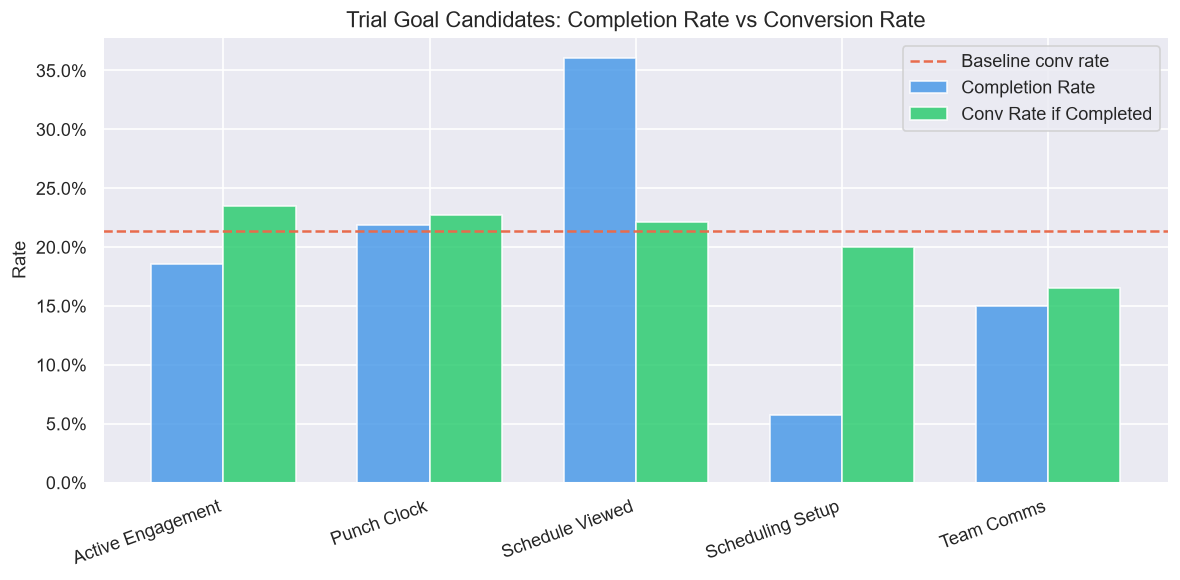

In [19]:
# Visualise goal completion vs conversion rate
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(goal_df))
width  = 0.35
labels = [g.replace('goal_', '').replace('_', ' ').title() for g in goal_df['goal']]

bars1 = ax.bar(x - width/2, goal_df['completion_rate'],
               width, label='Completion Rate', color='#4C9BE8', alpha=0.85)
bars2 = ax.bar(x + width/2, goal_df['conv_rate_if_completed'],
               width, label='Conv Rate if Completed', color='#2ECC71', alpha=0.85)

ax.axhline(org_feat['converted'].mean(), color='#E86B4C',
           linestyle='--', linewidth=1.5, label='Baseline conv rate')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Rate')
ax.set_title('Trial Goal Candidates: Completion Rate vs Conversion Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Summary & Recommended Trial Goals

Based on all four analysis methods, the following behaviours most strongly distinguish converting from non-converting organisations:

| # | Goal | Evidence |
|---|------|----------|
| G1 | **Scheduling Setup** — Create ≥1 shift AND set availability | Highest lift in activity analysis; top SHAP feature |
| G2 | **Schedule Viewed** — View schedule ≥3 times | High frequency among converters; signals ongoing engagement |
| G3 | **Team Communications** — Send ≥1 message | Strong Chi-squared signal; high converter adoption rate |
| G4 | **Punch Clock Activated** — Clock in/out at least once | Indicates operational go-live; high odds ratio |
| G5 | **Sustained Engagement** — Active on ≥5 distinct trial days | Strongest predictor of conversion (RF + SHAP) |

**Trial Activation** = completing ALL 5 goals within the 30-day trial.

> *These goals are hypotheses grounded in behavioural evidence. Completion rates should be monitored and thresholds refined as more data accumulates. A/B testing is recommended to confirm causal impact.*

In [20]:
# Save org-level feature matrix for Task 3
org_feat.to_parquet('../data/processed/org_features.parquet', index=False)
print('Saved -> org_features.parquet')
print(f'Shape: {org_feat.shape[0]:,} orgs x {org_feat.shape[1]} features')

Saved -> org_features.parquet
Shape: 966 orgs x 45 features
